Iteration    0: Cost 0.6930034414974452   
Iteration 10000: Cost 0.18911357359467018   
Iteration 20000: Cost 0.10356059365220438   
Iteration 30000: Cost 0.07071419345418097   
Iteration 40000: Cost 0.05354851247015955   
Iteration 50000: Cost 0.04304235498599437   
Iteration 60000: Cost 0.03596341623618956   
Iteration 70000: Cost 0.030875039521906452   
Iteration 80000: Cost 0.02704340336227558   
Iteration 90000: Cost 0.024055217703922088   

updated parameters: w:[4.01263979 3.54691399], b:0.1705895296278701


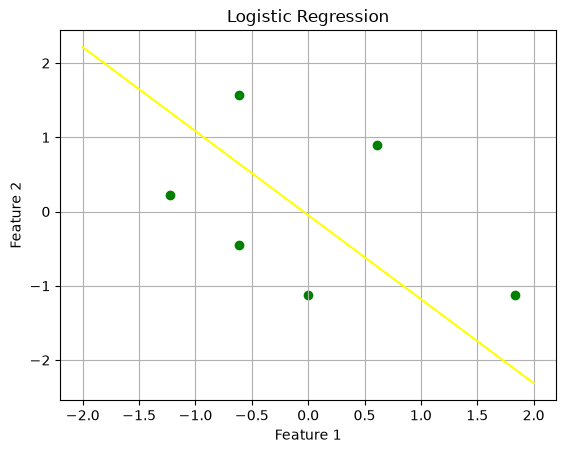

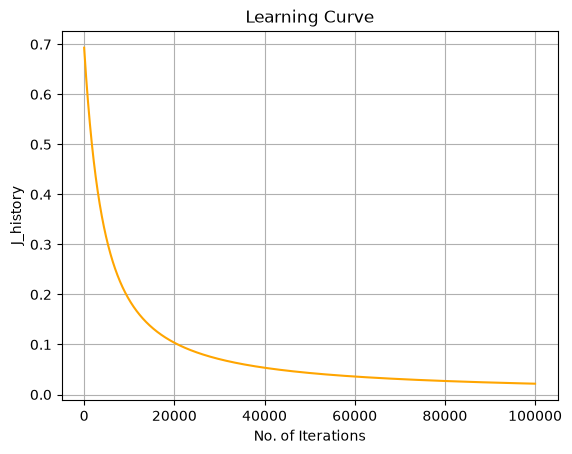

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import math

x_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

def sigmoid(z):
    return 1/ (1 + np.exp(-z))

def z_score_norm(x):
    mu = np.mean(x, axis = 0)
    s = np.std(x, axis = 0)
    x_norm = (x - mu)/s
    return x_norm, mu, s

x_train = z_score_norm(x_train)[0]

def compute_cost(x, y, w, b):
    cost = 0.0
    for i in range(len(x)):
        fx = sigmoid(np.dot(w,x[i]) + b)
        cost += (y[i] * np.log(fx)) + ((1-y[i]) * np.log(1 - fx))
    return cost / (-len(x))

def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        z = np.dot(w, x[i]) + b
        err = sigmoid(z) - y[i]
        for j in range(n):
            dj_dw[j] += err * x[i,j]
        dj_db += err

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

def gradient_descent(x, y, wi, bi, alpha, iters, cost_fn, gradient_fn):
    w = wi
    b = bi
    J = [cost_fn(x, y, w, b)]
    num_iters = [0]

    for i in range(iters):
        dj_dw, dj_db = gradient_fn(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J.append(cost_fn(x, y, w, b))
        num_iters.append(i)

        if i % math.ceil(iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J[-1]}   ")

    return w, b, J, num_iters

w_tmp = np.zeros_like(x_train[0])
b_tmp = 0.
alph = 0.001
iters = 100000

w_out, b_out, _, n = gradient_descent(x_train, y_train, w_tmp, b_tmp, alph, iters, compute_cost, compute_gradient)
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

plt.scatter(x_train[:,0], x_train[:,1], color = "green")
x1 = np.linspace(-2,2,50)
x2 = (-b_out - w_out[0] * x1)/w_out[1]
plt.plot(x1, x2, color = "yellow")
plt.title("Logistic Regression")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()

#plot the learning curve
plt.plot(n, _, color = "orange")
plt.title("Learning Curve")
plt.xlabel("No. of Iterations")
plt.ylabel("J_history")
plt.grid()
plt.show()
